In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import xarray as xr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *

In [2]:
import numpy as np
# Arithmetic mean of that score over members where it is finite; NaN if none are finite.
# Metadata are averaged too, so `n_valid` here is a mean cell count.
mean_member_scores = np.load(
    "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
    allow_pickle=True
).item()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
import inspect
import warnings

# Consistent model symbols across every field and both figure layouts.
PAIR_SHAPES = ["o", "s", "^", "v", "<", ">", "D", "d", "p", "h", "H", "8", "P", "X", "*", (4, 1, 0)]
HIST_COLOR, AMIP_COLOR = "#376996", "#D77A22"


def draw_model_mean_violin(ax, values, *, horizontal, color, bw_method="scott"):
    """One equally weighted value per MODEL; the violin is not an uncertainty CI."""
    values = np.asarray(values, dtype=float)
    if not len(values) or not np.isfinite(values).all():
        raise ValueError("Pass a nonempty, finite model-score vector to the marginal violin.")

    # A singleton or constant distribution has no KDE width. Show a short line at
    # its actual value instead of inventing a distribution or adding random noise.
    if len(values) < 2 or np.ptp(values) == 0:
        if horizontal:
            ax.vlines(values[0], -0.35, 0.35, color=color, linewidth=3)
        else:
            ax.hlines(values[0], -0.35, 0.35, color=color, linewidth=3)
    else:
        # Matplotlib renamed vert to orientation in 3.10; support both notebook
        # environments without requiring you to upgrade the cluster installation.
        direction = {"orientation": "horizontal" if horizontal else "vertical"}
        if "orientation" not in inspect.signature(ax.violinplot).parameters:
            direction = {"vert": not horizontal}
        parts = ax.violinplot(values, positions=[0], widths=0.85, showmeans=False,
                             showmedians=False, showextrema=False, points=150,
                             bw_method=bw_method, **direction)
        for body in parts["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.30)
            body.set_linewidth(0.8)

    # The top shares the scatter's x-axis; the right shares its y-axis.
    # Hide redundant ticks without changing the shared locators or labels.
    if horizontal:
        ax.set_ylim(-0.55, 0.55)
        ax.set_yticks([])
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    else:
        ax.set_xlim(-0.55, 0.55)
        ax.set_xticks([])
        ax.tick_params(axis="y", left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)


def add_paired_score_legend(fig, models, model_markers, model_colors, *, top=0.88):
    """One figure-level key outside the scatter AND its right marginal violin."""
    handles = [Line2D([], [], marker=model_markers[model], linestyle="none", markersize=8,
                      markerfacecolor=model_colors[model], markeredgecolor="black", label=model)
               for model in models]
    handles += [
        Line2D([], [], color="0.25", linewidth=1.2, label="1:1 agreement"),
        Line2D([], [], color="0.45", linewidth=1.5, linestyle="-.", label="OLS: AMIP on historical"),
        Line2D([], [], color=HIST_COLOR, linewidth=1.3, linestyle="--", label="Historical mean score (MMM)"),
        Line2D([], [], color=AMIP_COLOR, linewidth=1.3, linestyle="--", label="AMIP mean score (MMM)"),
    ]
    return fig.legend(handles=handles, title="Models / reference lines", loc="upper left",
                      bbox_to_anchor=(0.78, top), frameon=False, fontsize=9, title_fontsize=10)


def plot_paired_model_scores(table, model_markers, model_colors, *,
                             title="", score_label="Mean member spatial correlation with observations",
                             higher_is_better=True, limits=None, bounds=None, ax=None,
                             show_legend=True, marker_size=120, bw_method="scott", figsize=(11.5, 8.5)):
    """Historical on x; AMIP on y. One point, one vote, per paired model.

    Input columns: model, historical, amip. Optional metadata columns are retained.
    ALL statistics and both violins use the same pairwise-finite model set.
    Means are arithmetic means of model mean-member scores, NOT scores of MMM maps.
    OLS/r/R² are across-model descriptive statistics, not member/spatial correlations.
    Returns fig, axes dictionary, summary dictionary. No input scores are modified.
    """
    if table["model"].duplicated().any():
        raise ValueError("Each model must appear exactly once in a diagnostic's paired table.")
    finite = np.isfinite(table["historical"]) & np.isfinite(table["amip"])
    points = table.loc[finite].copy()
    n_dropped = int((~finite).sum())
    if points.empty:
        raise ValueError("No models have finite scores in both experiments.")
    if n_dropped:
        warnings.warn(f"{title}: excluding {n_dropped} nonfinite model pairs from points, fit, violins and MMMs.",
                      stacklevel=2)
    models = list(points["model"])
    if not all(model in model_markers and model in model_colors for model in models):
        raise ValueError("Every paired model needs a marker and color.")

    # These are already MEMBER-MEAN scores. Average over MODELS only: models with
    # many realizations do not receive extra weight in the fit, r, violins or MMMs.
    x, y = points["historical"].to_numpy(dtype=float), points["amip"].to_numpy(dtype=float)
    mean_x, mean_y = float(x.mean()), float(y.mean())
    dx, dy = x - mean_x, y - mean_y
    ss_x, ss_y, cross = float(dx @ dx), float(dy @ dy), float(dx @ dy)
    slope = cross / ss_x if len(x) >= 2 and np.ptp(x) > 0 else np.nan
    intercept = mean_y - slope * mean_x
    r = cross / np.sqrt(ss_x * ss_y) if np.ptp(x) > 0 and np.ptp(y) > 0 else np.nan
    r = float(np.clip(r, -1, 1))
    # R² = r² for this one-predictor OLS with an intercept; no independence-based
    # p-values/CIs are added, since climate models need not be independent.
    summary = {"n_models": len(x), "n_dropped": n_dropped, "r": r, "r_squared": r**2,
               "slope": slope, "intercept": intercept, "mean_historical": mean_x,
               "mean_amip": mean_y, "mean_amip_minus_historical": float((y - x).mean())}

    # Equal x/y ranges AND equal aspect make the 1:1 line geometrically honest.
    # Automatic limits span BOTH experiments. A manual crop changes display only;
    # report hidden points and still calculate statistics from every finite pair.
    if limits is None:
        low, high = float(min(x.min(), y.min())), float(max(x.max(), y.max()))
        pad = 0.08 * (high - low) if high > low else 0.08 * max(abs(low), 1.0)
        low, high = low - pad, high + pad
        if bounds is not None:
            low = max(low, bounds[0]) if bounds[0] is not None else low
            high = min(high, bounds[1]) if bounds[1] is not None else high
    else:
        low, high = map(float, limits)
    if not np.isfinite([low, high]).all() or low >= high:
        raise ValueError("Plot limits must be finite and strictly increasing.")
    cropped = int(((x < low) | (x > high) | (y < low) | (y > high)).sum())
    summary["n_outside_view"] = cropped
    if cropped:
        warnings.warn(f"{title}: {cropped} finite model points fall outside the plot limits; statistics are unchanged.",
                      stacklevel=2)

    # Append marginals to the scatter axes so they remain aligned in either a
    # standalone figure or one row of the combined three-panel figure.
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        fig.subplots_adjust(left=0.12, right=0.73, bottom=0.16, top=0.87)
    else:
        fig = ax.figure
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_aspect("equal", adjustable="box")
    divider = make_axes_locatable(ax)
    top = divider.append_axes("top", size="17%", pad=0.10, sharex=ax)
    right = divider.append_axes("right", size="17%", pad=0.10, sharey=ax)
    draw_model_mean_violin(top, x, horizontal=True, color=HIST_COLOR, bw_method=bw_method)
    draw_model_mean_violin(right, y, horizontal=False, color=AMIP_COLOR, bw_method=bw_method)

    # Diagonal = same score in the two experiments. The fitted line predicts
    # AMIP score from historical score and is drawn only across observed x values.
    ax.plot([low, high], [low, high], color="0.25", linewidth=1.2, zorder=1)
    if np.isfinite(slope):
        fit_x = np.linspace(x.min(), x.max(), 100)
        ax.plot(fit_x, intercept + slope * fit_x, color="0.45", linestyle="-.", linewidth=1.5, zorder=2)
    ax.axvline(mean_x, color=HIST_COLOR, linestyle="--", linewidth=1.3, zorder=1)
    ax.axhline(mean_y, color=AMIP_COLOR, linestyle="--", linewidth=1.3, zorder=1)
    top.axvline(mean_x, color=HIST_COLOR, linestyle="--", linewidth=1.3)
    right.axhline(mean_y, color=AMIP_COLOR, linestyle="--", linewidth=1.3)

    # Pair only MODEL summaries. Historical and AMIP realizations are not assumed
    # to correspond, so no artificial one-to-one member cloud is constructed.
    for row in points.itertuples():
        ax.scatter(row.historical, row.amip, marker=model_markers[row.model], s=marker_size,
                   color=model_colors[row.model], edgecolors="black", linewidths=0.8, zorder=3)

    top.set_title(f"{title}\nHistorical model means · MMM = {mean_x:.3g}", fontsize=12, pad=7)
    right.set_title(f"AMIP means\nMMM = {mean_y:.3g}", fontsize=9, pad=8)
    ax.set_xlabel(f"Coupled historical\n{score_label}", fontsize=11)
    ax.set_ylabel(f"AMIP-hist\n{score_label}", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.18, linewidth=0.6)

    # Show r as well as R²: squaring alone would hide a negative relationship.
    r_text = f"{r:.2f}" if np.isfinite(r) else "undefined"
    r2_text = f"{r**2:.2f}" if np.isfinite(r) else "undefined"
    annotation = f"Across models\nr = {r_text};  R² = {r2_text}\nn = {len(x)}"
    if n_dropped or cropped:
        annotation += f"\n{n_dropped} missing; {cropped} outside view"
    ax.text(1.03, 1.2, annotation, transform=ax.transAxes, ha="left", va="top", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.75", alpha=0.9))
    if higher_is_better is not None:
        direction = "Above" if higher_is_better else "Below"
        ax.text(0.98, 0.03, f"{direction} 1:1 → AMIP better", ha="right", va="bottom",
                transform=ax.transAxes, fontsize=9, color="0.3",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    if show_legend:
        add_paired_score_legend(fig, models, model_markers, model_colors)
    return fig, {"main": ax, "top": top, "right": right}, summary




# Set up for pattern_correlation

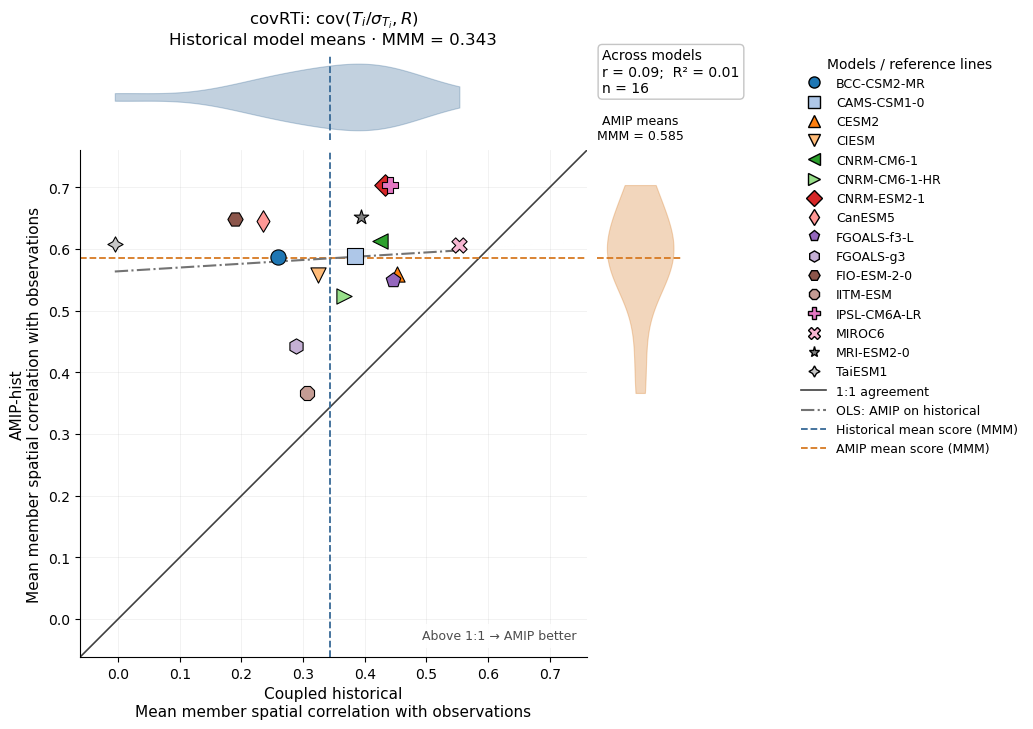

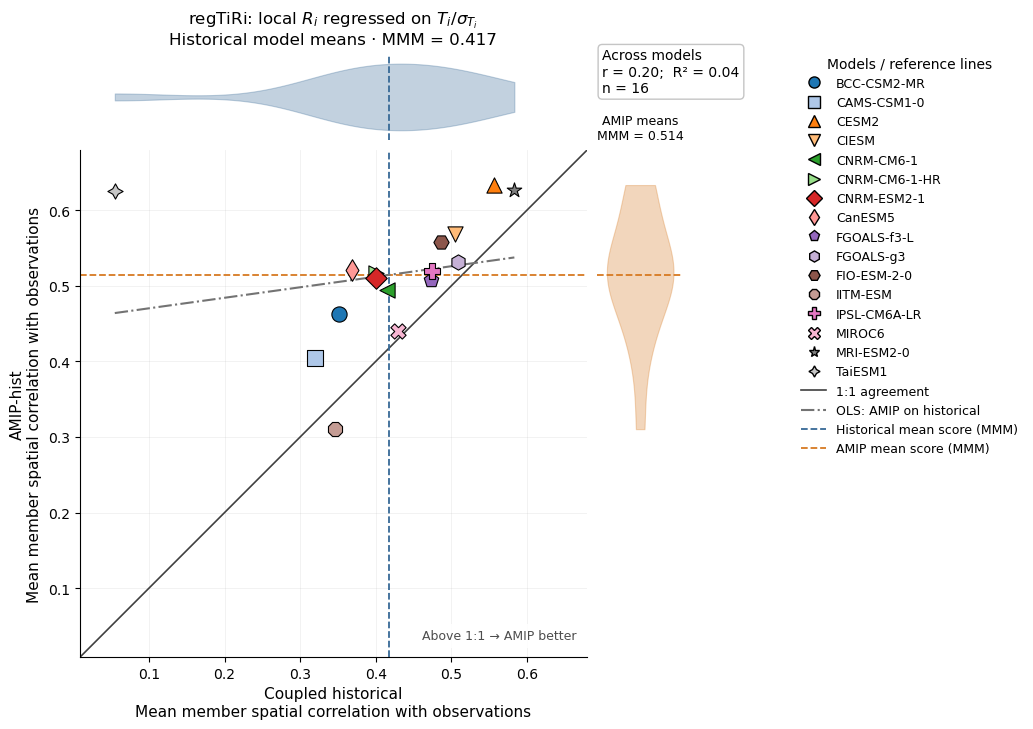

In [12]:
# Requires your saved mean_member_scores dictionary. It contains means of member
# scores against observations; do NOT substitute model_mean_scores or MMM_scores.
# In a fresh notebook, load the trusted saved file first:
# mean_member_scores = np.load("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
#                              allow_pickle=True).item()
save_plots = False
plot_score = "pattern_correlation"             # Or "rmse", "centered_rmse", "lin_ccc", etc.

comparison_metrics = ["covRTi", "covTRi", "regTiRi"]
historical_experiment, amip_experiment = "historical_matched", "amip_hist"

# Labels refer to the DIAGNOSTIC map compared with observations. Physical RMSE
# has radiation units for covRTi/regTiRi, but temperature units for covTRi.
diagnostic_titles = {
    "covRTi": r"covRTi: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$",
    "covTRi": r"covTRi: $\mathrm{cov}(R_i/\sigma_{R_i}, T)$",
    "regTiRi": r"regTiRi: local $R_i$ regressed on $T_i/\sigma_{T_i}$",
}
diagnostic_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
score_options = {
    "pattern_correlation": ("Mean member spatial correlation with observations", True, (-1, 1)),
    "lin_ccc": ("Mean member Lin's CCC with observations", True, (-1, 1)),
    "cosine": ("Mean member cosine with observations", True, (-1, 1)),
    "rmse": ("Mean member RMSE against observations", False, (0, None)),
    "centered_rmse": ("Mean member centered RMSE against observations", False, (0, None)),
    "rmse_over_rms_x": ("Mean member RMSE / observational RMS", False, (0, None)),
    "rmse_over_std_x": ("Mean member RMSE / observational spatial SD", False, (0, None)),
    "centered_rmse_over_std_x": ("Mean member centered RMSE / observational spatial SD", False, (0, None)),
}
score_label, higher_is_better, score_bounds = score_options.get(plot_score, (f"Mean member {plot_score}", None, None))
# For an unlisted score, set its label/direction/bounds here. Signed bias and
# amplitude ratios do NOT have a universal "larger is better" interpretation.
scatter_limits = None                         # Or (0, 1), (-1, 1), etc.; identical x/y limits.
violin_bandwidth = "scott"                     # Or "silverman", or a positive numeric KDE factor.
comparison_plot_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/historical_vs_amip")
if save_plots:
    comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# Check model identities before building rows; paired values are looked up by
# name even when experiment dictionaries were saved in different model orders.
comparison_models = list(mean_member_scores[amip_experiment][comparison_metrics[0]])
paired_model_scores = {}
for metric in comparison_metrics:
    hist = mean_member_scores[historical_experiment][metric]
    amip = mean_member_scores[amip_experiment][metric]
    if not comparison_models or set(hist) != set(comparison_models) or set(amip) != set(comparison_models):
        raise ValueError(f"{metric}: all fields must use the same matched historical/AMIP model set.")
    rows = [(model, float(hist[model][plot_score]), float(amip[model][plot_score])) for model in comparison_models]
    paired_model_scores[metric] = pd.DataFrame(rows, columns=["model", "historical", "amip"])
    paired_model_scores[metric]["metric"] = metric
    paired_model_scores[metric]["score"] = plot_score
    paired_model_scores[metric]["valid_pair"] = np.isfinite(paired_model_scores[metric][["historical", "amip"]]).all(axis=1)

# Missing scores are excluded PAIRWISE within each field, including from BOTH
# marginal violins and MMM lines. Sample counts are reported in each panel.
# Set this True if you also want precisely the same finite models in all fields.
common_finite_models = False
if common_finite_models:
    common_valid = np.logical_and.reduce([paired_model_scores[m]["valid_pair"].to_numpy() for m in comparison_metrics])
    for metric in comparison_metrics:
        paired_model_scores[metric] = paired_model_scores[metric].loc[common_valid].copy()
    print(f"Common finite subset: {common_valid.sum()} / {len(comparison_models)} matched models.")

# Reuse these mappings for all separate/combined panels. To match your own
# colors_16/filled_markers, replace the dictionaries with zipped model-name maps.
pair_model_markers = {model: PAIR_SHAPES[i % len(PAIR_SHAPES)] for i, model in enumerate(comparison_models)}
palette = plt.get_cmap("tab20").colors
pair_model_colors = {model: palette[i % len(palette)] for i, model in enumerate(comparison_models)}
# pair_model_markers = dict(zip(comparison_models, filled_markers))
# pair_model_colors = dict(zip(comparison_models, colors_16))

# Keep actual plotting arguments and output summaries inspectable by field.
pair_plot_labels = {metric: score_label for metric in comparison_metrics}
if plot_score in ["rmse", "centered_rmse", "bias"]:
    pair_plot_labels = {metric: f"{score_label} [{diagnostic_units[metric]}]" for metric in comparison_metrics}
paired_scatter_figures, paired_scatter_axes, paired_scatter_stats = {}, {}, {}





metric = "covRTi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()

metric = "regTiRi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()


# RMSE / RMS_obs

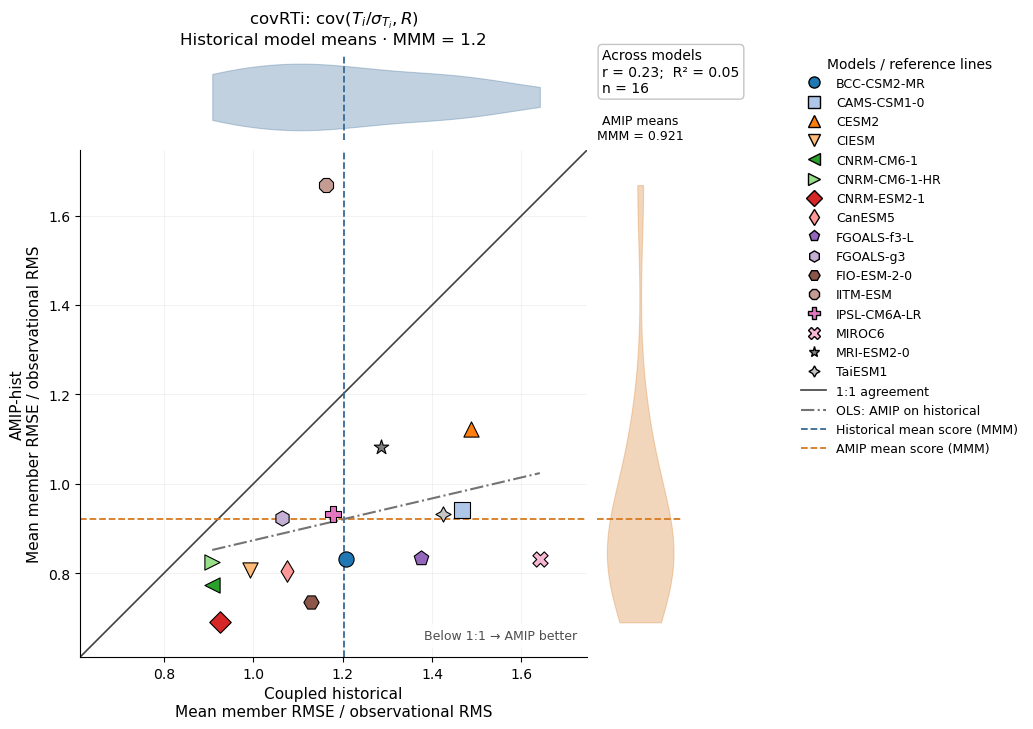

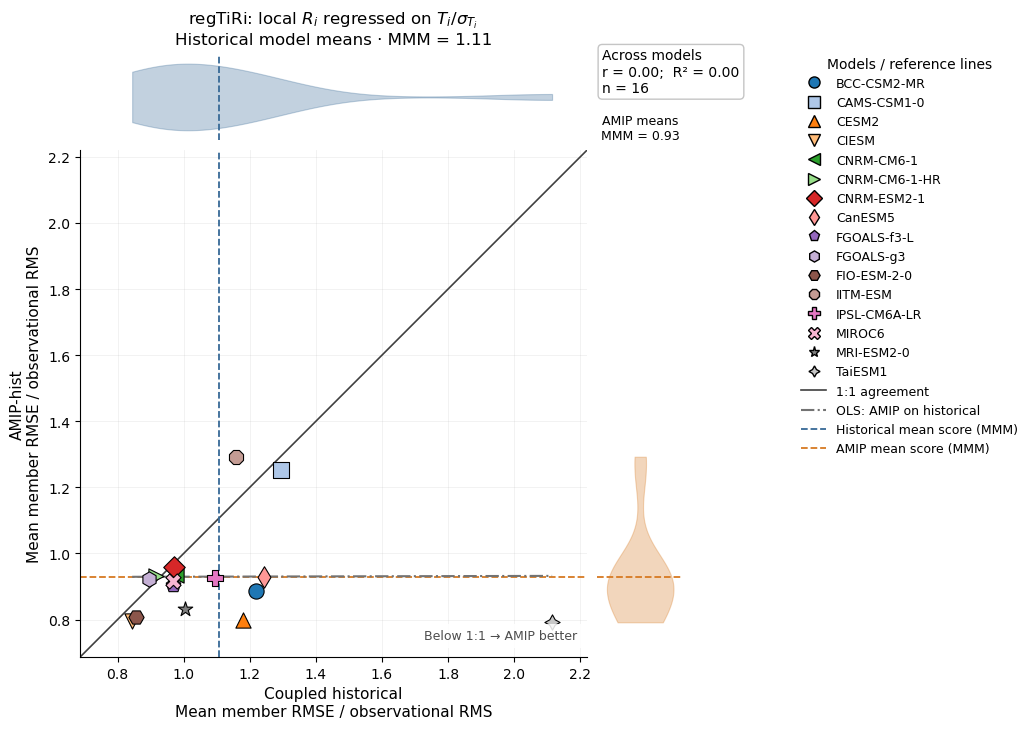

In [13]:
# Requires your saved mean_member_scores dictionary. It contains means of member
# scores against observations; do NOT substitute model_mean_scores or MMM_scores.
# In a fresh notebook, load the trusted saved file first:
# mean_member_scores = np.load("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
#                              allow_pickle=True).item()
save_plots = True
plot_score = "rmse_over_rms_x"             # Or "rmse", "centered_rmse", "lin_ccc", etc.

comparison_metrics = ["covRTi", "covTRi", "regTiRi"]
historical_experiment, amip_experiment = "historical_matched", "amip_hist"

# Labels refer to the DIAGNOSTIC map compared with observations. Physical RMSE
# has radiation units for covRTi/regTiRi, but temperature units for covTRi.
diagnostic_titles = {
    "covRTi": r"covRTi: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$",
    "covTRi": r"covTRi: $\mathrm{cov}(R_i/\sigma_{R_i}, T)$",
    "regTiRi": r"regTiRi: local $R_i$ regressed on $T_i/\sigma_{T_i}$",
}
diagnostic_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
score_options = {
    "pattern_correlation": ("Mean member spatial correlation with observations", True, (-1, 1)),
    "lin_ccc": ("Mean member Lin's CCC with observations", True, (-1, 1)),
    "cosine": ("Mean member cosine with observations", True, (-1, 1)),
    "rmse": ("Mean member RMSE against observations", False, (0, None)),
    "centered_rmse": ("Mean member centered RMSE against observations", False, (0, None)),
    "rmse_over_rms_x": ("Mean member RMSE / observational RMS", False, (0, None)),
    "rmse_over_std_x": ("Mean member RMSE / observational spatial SD", False, (0, None)),
    "centered_rmse_over_std_x": ("Mean member centered RMSE / observational spatial SD", False, (0, None)),
}
score_label, higher_is_better, score_bounds = score_options.get(plot_score, (f"Mean member {plot_score}", None, None))
# For an unlisted score, set its label/direction/bounds here. Signed bias and
# amplitude ratios do NOT have a universal "larger is better" interpretation.
scatter_limits = None                         # Or (0, 1), (-1, 1), etc.; identical x/y limits.
violin_bandwidth = "scott"                     # Or "silverman", or a positive numeric KDE factor.
comparison_plot_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/historical_vs_amip")
if save_plots:
    comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# Check model identities before building rows; paired values are looked up by
# name even when experiment dictionaries were saved in different model orders.
comparison_models = list(mean_member_scores[amip_experiment][comparison_metrics[0]])
paired_model_scores = {}
for metric in comparison_metrics:
    hist = mean_member_scores[historical_experiment][metric]
    amip = mean_member_scores[amip_experiment][metric]
    if not comparison_models or set(hist) != set(comparison_models) or set(amip) != set(comparison_models):
        raise ValueError(f"{metric}: all fields must use the same matched historical/AMIP model set.")
    rows = [(model, float(hist[model][plot_score]), float(amip[model][plot_score])) for model in comparison_models]
    paired_model_scores[metric] = pd.DataFrame(rows, columns=["model", "historical", "amip"])
    paired_model_scores[metric]["metric"] = metric
    paired_model_scores[metric]["score"] = plot_score
    paired_model_scores[metric]["valid_pair"] = np.isfinite(paired_model_scores[metric][["historical", "amip"]]).all(axis=1)

# Missing scores are excluded PAIRWISE within each field, including from BOTH
# marginal violins and MMM lines. Sample counts are reported in each panel.
# Set this True if you also want precisely the same finite models in all fields.
common_finite_models = False
if common_finite_models:
    common_valid = np.logical_and.reduce([paired_model_scores[m]["valid_pair"].to_numpy() for m in comparison_metrics])
    for metric in comparison_metrics:
        paired_model_scores[metric] = paired_model_scores[metric].loc[common_valid].copy()
    print(f"Common finite subset: {common_valid.sum()} / {len(comparison_models)} matched models.")

# Reuse these mappings for all separate/combined panels. To match your own
# colors_16/filled_markers, replace the dictionaries with zipped model-name maps.
pair_model_markers = {model: PAIR_SHAPES[i % len(PAIR_SHAPES)] for i, model in enumerate(comparison_models)}
palette = plt.get_cmap("tab20").colors
pair_model_colors = {model: palette[i % len(palette)] for i, model in enumerate(comparison_models)}
# pair_model_markers = dict(zip(comparison_models, filled_markers))
# pair_model_colors = dict(zip(comparison_models, colors_16))

# Keep actual plotting arguments and output summaries inspectable by field.
pair_plot_labels = {metric: score_label for metric in comparison_metrics}
if plot_score in ["rmse", "centered_rmse", "bias"]:
    pair_plot_labels = {metric: f"{score_label} [{diagnostic_units[metric]}]" for metric in comparison_metrics}
paired_scatter_figures, paired_scatter_axes, paired_scatter_stats = {}, {}, {}





metric = "covRTi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()

metric = "regTiRi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()


# Lin's CCC

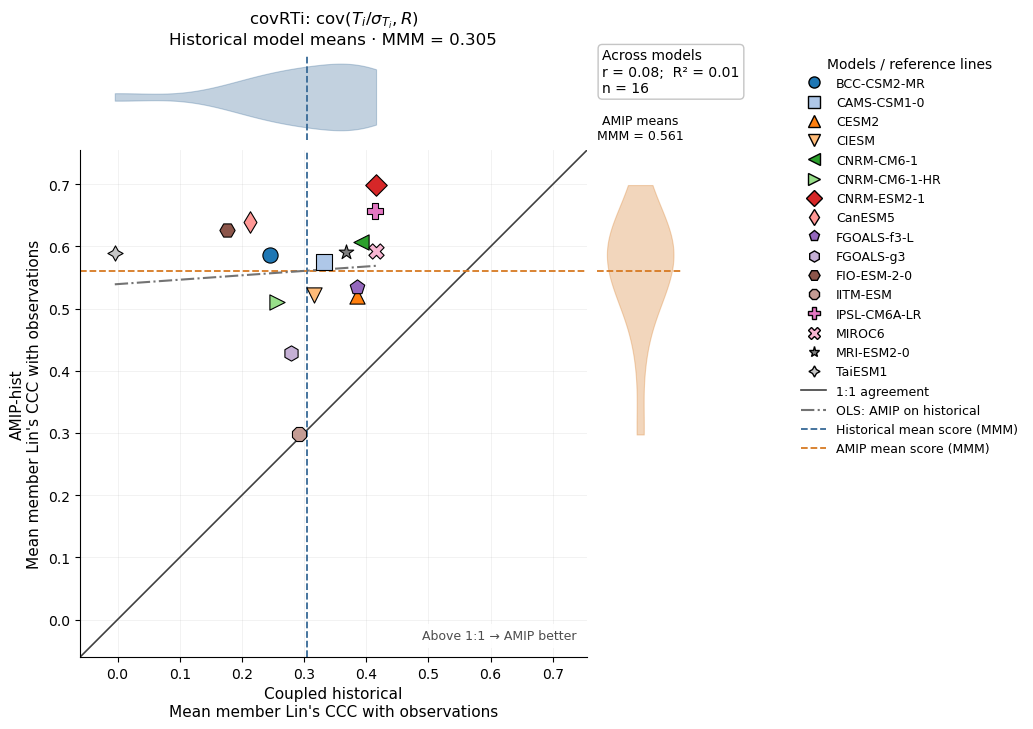

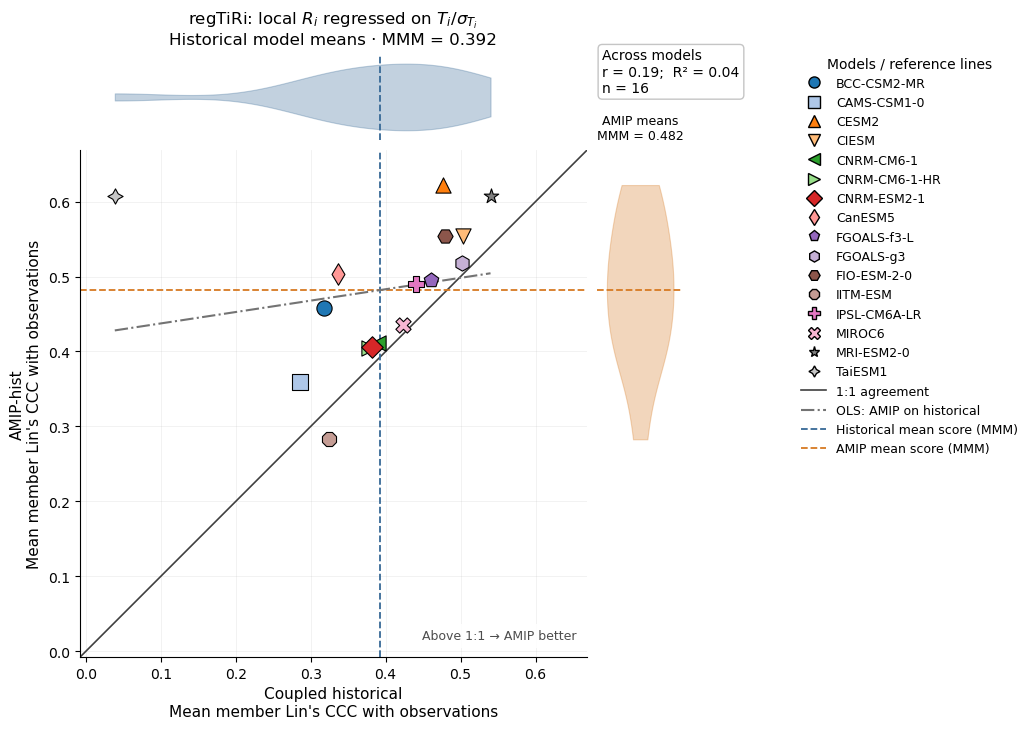

In [14]:
# Requires your saved mean_member_scores dictionary. It contains means of member
# scores against observations; do NOT substitute model_mean_scores or MMM_scores.
# In a fresh notebook, load the trusted saved file first:
# mean_member_scores = np.load("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
#                              allow_pickle=True).item()
save_plots = True
plot_score = "lin_ccc"             # Or "rmse", "centered_rmse", "lin_ccc", etc.

comparison_metrics = ["covRTi", "covTRi", "regTiRi"]
historical_experiment, amip_experiment = "historical_matched", "amip_hist"

# Labels refer to the DIAGNOSTIC map compared with observations. Physical RMSE
# has radiation units for covRTi/regTiRi, but temperature units for covTRi.
diagnostic_titles = {
    "covRTi": r"covRTi: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$",
    "covTRi": r"covTRi: $\mathrm{cov}(R_i/\sigma_{R_i}, T)$",
    "regTiRi": r"regTiRi: local $R_i$ regressed on $T_i/\sigma_{T_i}$",
}
diagnostic_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
score_options = {
    "pattern_correlation": ("Mean member spatial correlation with observations", True, (-1, 1)),
    "lin_ccc": ("Mean member Lin's CCC with observations", True, (-1, 1)),
    "cosine": ("Mean member cosine with observations", True, (-1, 1)),
    "rmse": ("Mean member RMSE against observations", False, (0, None)),
    "centered_rmse": ("Mean member centered RMSE against observations", False, (0, None)),
    "rmse_over_rms_x": ("Mean member RMSE / observational RMS", False, (0, None)),
    "rmse_over_std_x": ("Mean member RMSE / observational spatial SD", False, (0, None)),
    "centered_rmse_over_std_x": ("Mean member centered RMSE / observational spatial SD", False, (0, None)),
}
score_label, higher_is_better, score_bounds = score_options.get(plot_score, (f"Mean member {plot_score}", None, None))
# For an unlisted score, set its label/direction/bounds here. Signed bias and
# amplitude ratios do NOT have a universal "larger is better" interpretation.
scatter_limits = None                         # Or (0, 1), (-1, 1), etc.; identical x/y limits.
violin_bandwidth = "scott"                     # Or "silverman", or a positive numeric KDE factor.
comparison_plot_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/historical_vs_amip")
if save_plots:
    comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# Check model identities before building rows; paired values are looked up by
# name even when experiment dictionaries were saved in different model orders.
comparison_models = list(mean_member_scores[amip_experiment][comparison_metrics[0]])
paired_model_scores = {}
for metric in comparison_metrics:
    hist = mean_member_scores[historical_experiment][metric]
    amip = mean_member_scores[amip_experiment][metric]
    if not comparison_models or set(hist) != set(comparison_models) or set(amip) != set(comparison_models):
        raise ValueError(f"{metric}: all fields must use the same matched historical/AMIP model set.")
    rows = [(model, float(hist[model][plot_score]), float(amip[model][plot_score])) for model in comparison_models]
    paired_model_scores[metric] = pd.DataFrame(rows, columns=["model", "historical", "amip"])
    paired_model_scores[metric]["metric"] = metric
    paired_model_scores[metric]["score"] = plot_score
    paired_model_scores[metric]["valid_pair"] = np.isfinite(paired_model_scores[metric][["historical", "amip"]]).all(axis=1)

# Missing scores are excluded PAIRWISE within each field, including from BOTH
# marginal violins and MMM lines. Sample counts are reported in each panel.
# Set this True if you also want precisely the same finite models in all fields.
common_finite_models = False
if common_finite_models:
    common_valid = np.logical_and.reduce([paired_model_scores[m]["valid_pair"].to_numpy() for m in comparison_metrics])
    for metric in comparison_metrics:
        paired_model_scores[metric] = paired_model_scores[metric].loc[common_valid].copy()
    print(f"Common finite subset: {common_valid.sum()} / {len(comparison_models)} matched models.")

# Reuse these mappings for all separate/combined panels. To match your own
# colors_16/filled_markers, replace the dictionaries with zipped model-name maps.
pair_model_markers = {model: PAIR_SHAPES[i % len(PAIR_SHAPES)] for i, model in enumerate(comparison_models)}
palette = plt.get_cmap("tab20").colors
pair_model_colors = {model: palette[i % len(palette)] for i, model in enumerate(comparison_models)}
# pair_model_markers = dict(zip(comparison_models, filled_markers))
# pair_model_colors = dict(zip(comparison_models, colors_16))

# Keep actual plotting arguments and output summaries inspectable by field.
pair_plot_labels = {metric: score_label for metric in comparison_metrics}
if plot_score in ["rmse", "centered_rmse", "bias"]:
    pair_plot_labels = {metric: f"{score_label} [{diagnostic_units[metric]}]" for metric in comparison_metrics}
paired_scatter_figures, paired_scatter_axes, paired_scatter_stats = {}, {}, {}





metric = "covRTi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()

metric = "regTiRi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()


# Mean member centered RMSE / observational spatial SD

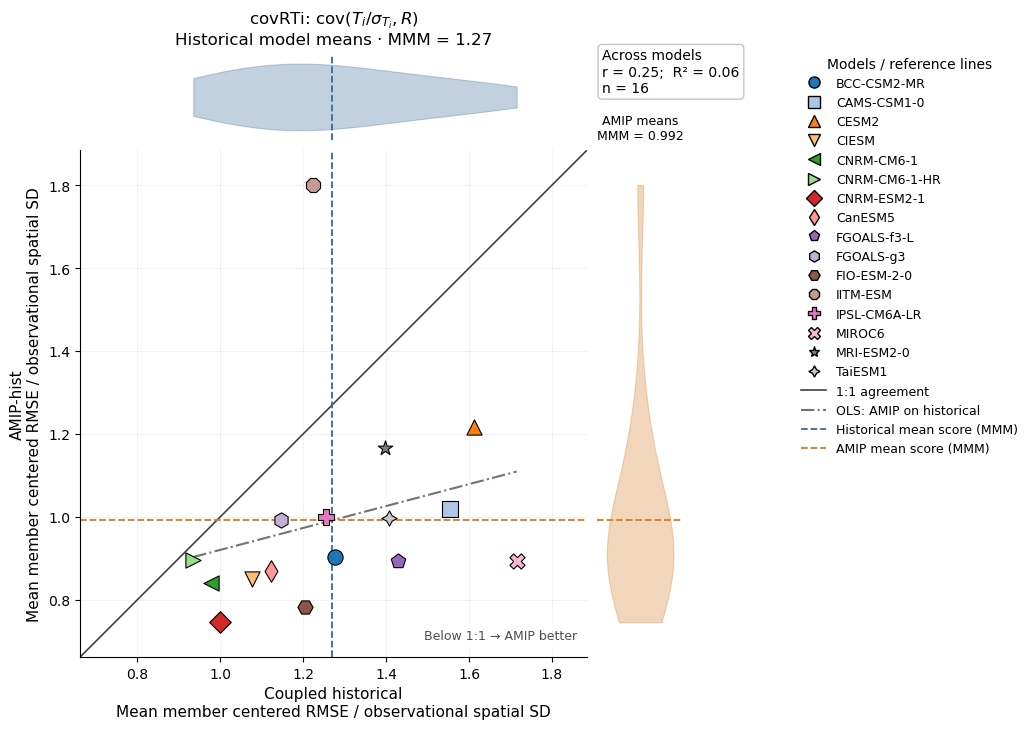

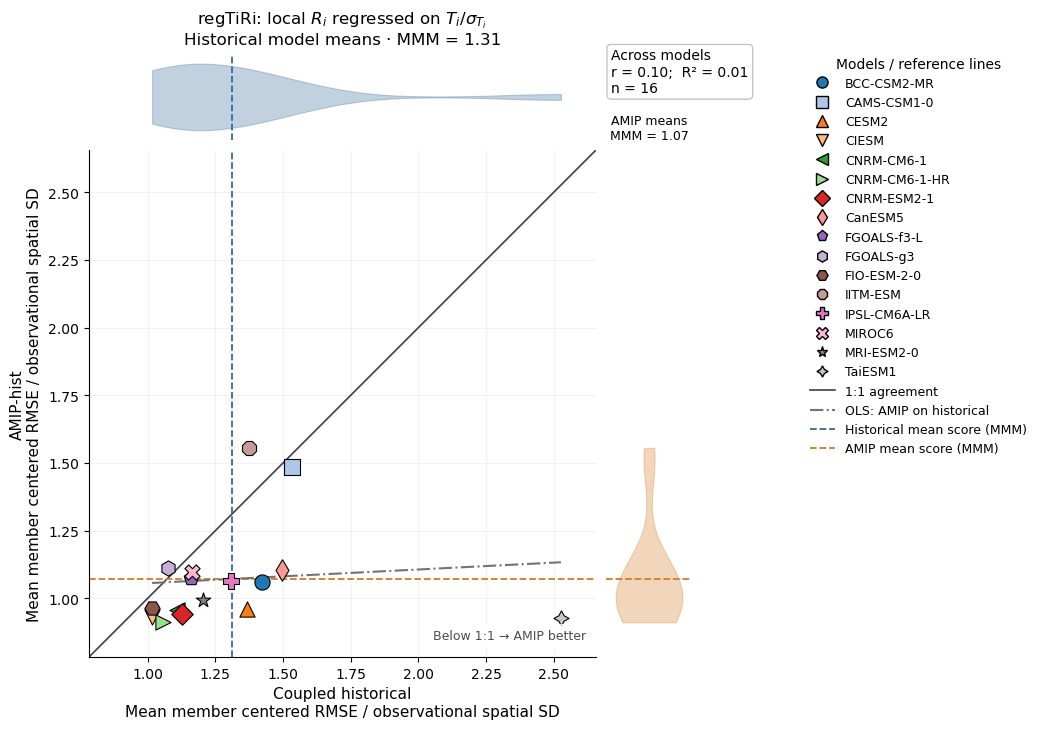

In [15]:
# Requires your saved mean_member_scores dictionary. It contains means of member
# scores against observations; do NOT substitute model_mean_scores or MMM_scores.
# In a fresh notebook, load the trusted saved file first:
# mean_member_scores = np.load("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
#                              allow_pickle=True).item()
save_plots = True
plot_score = "centered_rmse_over_std_x"             # Or "rmse", "centered_rmse", "lin_ccc", etc.

comparison_metrics = ["covRTi", "covTRi", "regTiRi"]
historical_experiment, amip_experiment = "historical_matched", "amip_hist"

# Labels refer to the DIAGNOSTIC map compared with observations. Physical RMSE
# has radiation units for covRTi/regTiRi, but temperature units for covTRi.
diagnostic_titles = {
    "covRTi": r"covRTi: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$",
    "covTRi": r"covTRi: $\mathrm{cov}(R_i/\sigma_{R_i}, T)$",
    "regTiRi": r"regTiRi: local $R_i$ regressed on $T_i/\sigma_{T_i}$",
}
diagnostic_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
score_options = {
    "pattern_correlation": ("Mean member spatial correlation with observations", True, (-1, 1)),
    "lin_ccc": ("Mean member Lin's CCC with observations", True, (-1, 1)),
    "cosine": ("Mean member cosine with observations", True, (-1, 1)),
    "rmse": ("Mean member RMSE against observations", False, (0, None)),
    "centered_rmse": ("Mean member centered RMSE against observations", False, (0, None)),
    "rmse_over_rms_x": ("Mean member RMSE / observational RMS", False, (0, None)),
    "rmse_over_std_x": ("Mean member RMSE / observational spatial SD", False, (0, None)),
    "centered_rmse_over_std_x": ("Mean member centered RMSE / observational spatial SD", False, (0, None)),
}
score_label, higher_is_better, score_bounds = score_options.get(plot_score, (f"Mean member {plot_score}", None, None))
# For an unlisted score, set its label/direction/bounds here. Signed bias and
# amplitude ratios do NOT have a universal "larger is better" interpretation.
scatter_limits = None                         # Or (0, 1), (-1, 1), etc.; identical x/y limits.
violin_bandwidth = "scott"                     # Or "silverman", or a positive numeric KDE factor.
comparison_plot_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/historical_vs_amip")
if save_plots:
    comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# Check model identities before building rows; paired values are looked up by
# name even when experiment dictionaries were saved in different model orders.
comparison_models = list(mean_member_scores[amip_experiment][comparison_metrics[0]])
paired_model_scores = {}
for metric in comparison_metrics:
    hist = mean_member_scores[historical_experiment][metric]
    amip = mean_member_scores[amip_experiment][metric]
    if not comparison_models or set(hist) != set(comparison_models) or set(amip) != set(comparison_models):
        raise ValueError(f"{metric}: all fields must use the same matched historical/AMIP model set.")
    rows = [(model, float(hist[model][plot_score]), float(amip[model][plot_score])) for model in comparison_models]
    paired_model_scores[metric] = pd.DataFrame(rows, columns=["model", "historical", "amip"])
    paired_model_scores[metric]["metric"] = metric
    paired_model_scores[metric]["score"] = plot_score
    paired_model_scores[metric]["valid_pair"] = np.isfinite(paired_model_scores[metric][["historical", "amip"]]).all(axis=1)

# Missing scores are excluded PAIRWISE within each field, including from BOTH
# marginal violins and MMM lines. Sample counts are reported in each panel.
# Set this True if you also want precisely the same finite models in all fields.
common_finite_models = False
if common_finite_models:
    common_valid = np.logical_and.reduce([paired_model_scores[m]["valid_pair"].to_numpy() for m in comparison_metrics])
    for metric in comparison_metrics:
        paired_model_scores[metric] = paired_model_scores[metric].loc[common_valid].copy()
    print(f"Common finite subset: {common_valid.sum()} / {len(comparison_models)} matched models.")

# Reuse these mappings for all separate/combined panels. To match your own
# colors_16/filled_markers, replace the dictionaries with zipped model-name maps.
pair_model_markers = {model: PAIR_SHAPES[i % len(PAIR_SHAPES)] for i, model in enumerate(comparison_models)}
palette = plt.get_cmap("tab20").colors
pair_model_colors = {model: palette[i % len(palette)] for i, model in enumerate(comparison_models)}
# pair_model_markers = dict(zip(comparison_models, filled_markers))
# pair_model_colors = dict(zip(comparison_models, colors_16))

# Keep actual plotting arguments and output summaries inspectable by field.
pair_plot_labels = {metric: score_label for metric in comparison_metrics}
if plot_score in ["rmse", "centered_rmse", "bias"]:
    pair_plot_labels = {metric: f"{score_label} [{diagnostic_units[metric]}]" for metric in comparison_metrics}
paired_scatter_figures, paired_scatter_axes, paired_scatter_stats = {}, {}, {}





metric = "covRTi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()

metric = "regTiRi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()


# RMSE

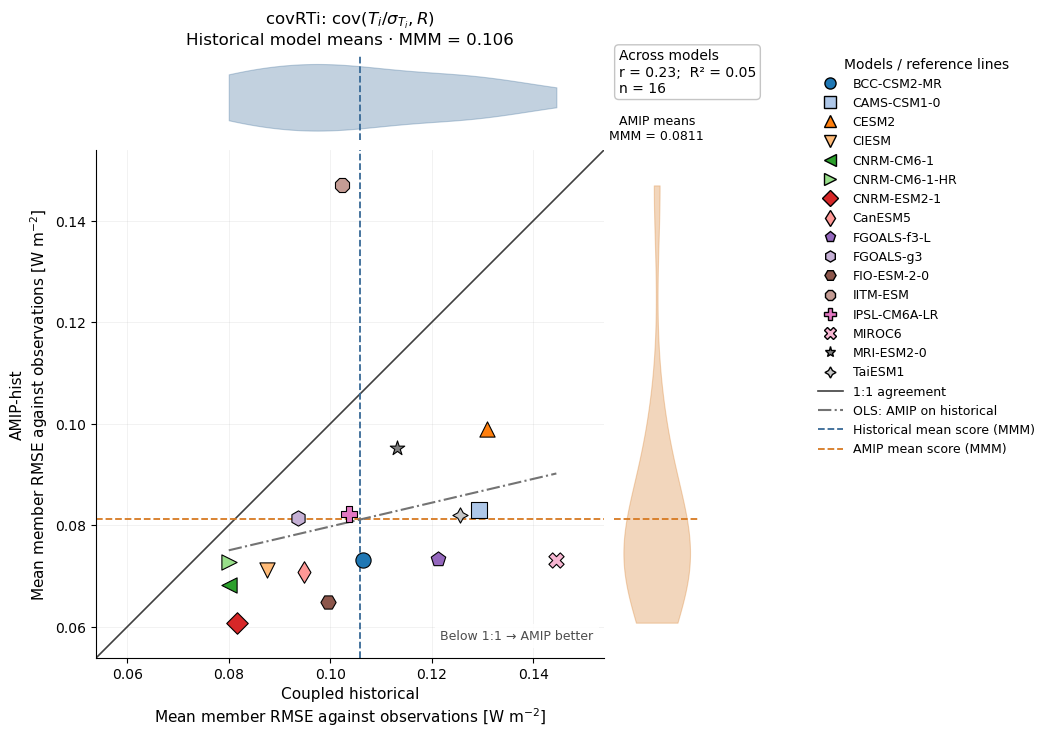

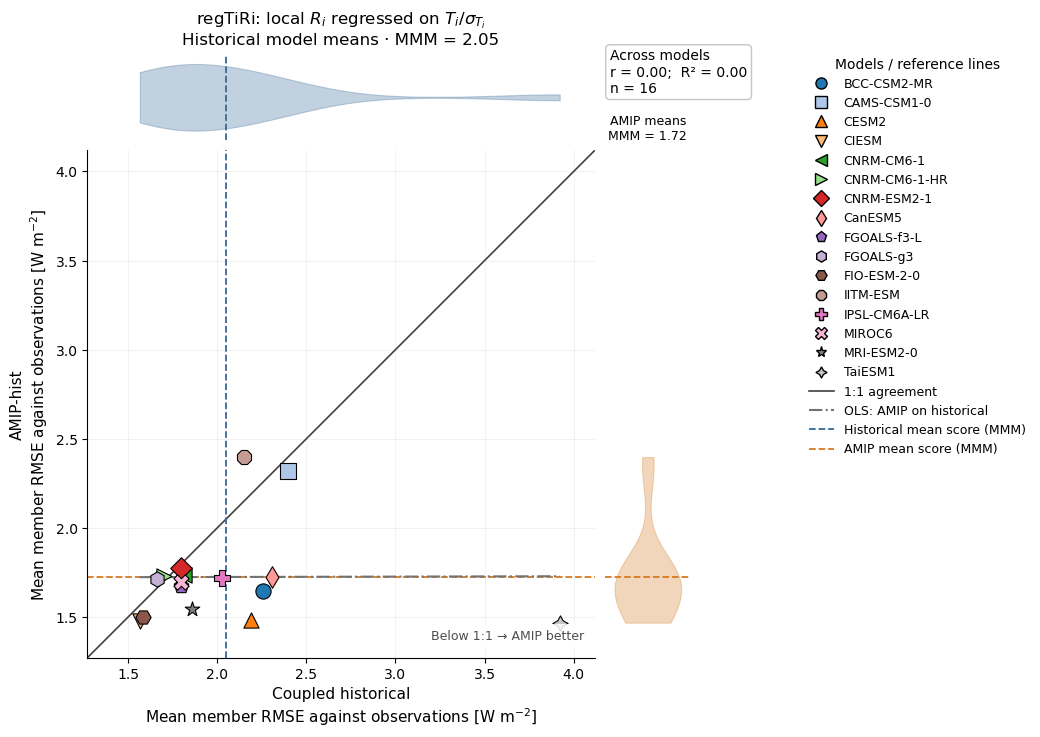

In [16]:
# Requires your saved mean_member_scores dictionary. It contains means of member
# scores against observations; do NOT substitute model_mean_scores or MMM_scores.
# In a fresh notebook, load the trusted saved file first:
# mean_member_scores = np.load("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/vs_obs/mean_member_scores.npy",
#                              allow_pickle=True).item()
save_plots = True
plot_score = "rmse"             # Or "rmse", "centered_rmse", "lin_ccc", etc.

comparison_metrics = ["covRTi", "covTRi", "regTiRi"]
historical_experiment, amip_experiment = "historical_matched", "amip_hist"

# Labels refer to the DIAGNOSTIC map compared with observations. Physical RMSE
# has radiation units for covRTi/regTiRi, but temperature units for covTRi.
diagnostic_titles = {
    "covRTi": r"covRTi: $\mathrm{cov}(T_i/\sigma_{T_i}, R)$",
    "covTRi": r"covTRi: $\mathrm{cov}(R_i/\sigma_{R_i}, T)$",
    "regTiRi": r"regTiRi: local $R_i$ regressed on $T_i/\sigma_{T_i}$",
}
diagnostic_units = {"covRTi": r"W m$^{-2}$", "covTRi": "K", "regTiRi": r"W m$^{-2}$"}
score_options = {
    "pattern_correlation": ("Mean member spatial correlation with observations", True, (-1, 1)),
    "lin_ccc": ("Mean member Lin's CCC with observations", True, (-1, 1)),
    "cosine": ("Mean member cosine with observations", True, (-1, 1)),
    "rmse": ("Mean member RMSE against observations", False, (0, None)),
    "centered_rmse": ("Mean member centered RMSE against observations", False, (0, None)),
    "rmse_over_rms_x": ("Mean member RMSE / observational RMS", False, (0, None)),
    "rmse_over_std_x": ("Mean member RMSE / observational spatial SD", False, (0, None)),
    "centered_rmse_over_std_x": ("Mean member centered RMSE / observational spatial SD", False, (0, None)),
}
score_label, higher_is_better, score_bounds = score_options.get(plot_score, (f"Mean member {plot_score}", None, None))
# For an unlisted score, set its label/direction/bounds here. Signed bias and
# amplitude ratios do NOT have a universal "larger is better" interpretation.
scatter_limits = None                         # Or (0, 1), (-1, 1), etc.; identical x/y limits.
violin_bandwidth = "scott"                     # Or "silverman", or a positive numeric KDE factor.
comparison_plot_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/historical_vs_amip")
if save_plots:
    comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# Check model identities before building rows; paired values are looked up by
# name even when experiment dictionaries were saved in different model orders.
comparison_models = list(mean_member_scores[amip_experiment][comparison_metrics[0]])
paired_model_scores = {}
for metric in comparison_metrics:
    hist = mean_member_scores[historical_experiment][metric]
    amip = mean_member_scores[amip_experiment][metric]
    if not comparison_models or set(hist) != set(comparison_models) or set(amip) != set(comparison_models):
        raise ValueError(f"{metric}: all fields must use the same matched historical/AMIP model set.")
    rows = [(model, float(hist[model][plot_score]), float(amip[model][plot_score])) for model in comparison_models]
    paired_model_scores[metric] = pd.DataFrame(rows, columns=["model", "historical", "amip"])
    paired_model_scores[metric]["metric"] = metric
    paired_model_scores[metric]["score"] = plot_score
    paired_model_scores[metric]["valid_pair"] = np.isfinite(paired_model_scores[metric][["historical", "amip"]]).all(axis=1)

# Missing scores are excluded PAIRWISE within each field, including from BOTH
# marginal violins and MMM lines. Sample counts are reported in each panel.
# Set this True if you also want precisely the same finite models in all fields.
common_finite_models = False
if common_finite_models:
    common_valid = np.logical_and.reduce([paired_model_scores[m]["valid_pair"].to_numpy() for m in comparison_metrics])
    for metric in comparison_metrics:
        paired_model_scores[metric] = paired_model_scores[metric].loc[common_valid].copy()
    print(f"Common finite subset: {common_valid.sum()} / {len(comparison_models)} matched models.")

# Reuse these mappings for all separate/combined panels. To match your own
# colors_16/filled_markers, replace the dictionaries with zipped model-name maps.
pair_model_markers = {model: PAIR_SHAPES[i % len(PAIR_SHAPES)] for i, model in enumerate(comparison_models)}
palette = plt.get_cmap("tab20").colors
pair_model_colors = {model: palette[i % len(palette)] for i, model in enumerate(comparison_models)}
# pair_model_markers = dict(zip(comparison_models, filled_markers))
# pair_model_colors = dict(zip(comparison_models, colors_16))

# Keep actual plotting arguments and output summaries inspectable by field.
pair_plot_labels = {metric: score_label for metric in comparison_metrics}
if plot_score in ["rmse", "centered_rmse", "bias"]:
    pair_plot_labels = {metric: f"{score_label} [{diagnostic_units[metric]}]" for metric in comparison_metrics}
paired_scatter_figures, paired_scatter_axes, paired_scatter_stats = {}, {}, {}





metric = "covRTi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()

metric = "regTiRi"
fig, axes, summary = plot_paired_model_scores(
    paired_model_scores[metric], pair_model_markers, pair_model_colors,
    title=diagnostic_titles[metric], score_label=pair_plot_labels[metric],
    higher_is_better=higher_is_better, limits=scatter_limits, bounds=score_bounds, bw_method=violin_bandwidth
)
paired_scatter_figures[metric], paired_scatter_axes[metric], paired_scatter_stats[metric] = fig, axes, summary
if save_plots:
    fig.savefig(comparison_plot_dir / f"paired_{metric}_{plot_score}.png", bbox_inches="tight")
plt.show()
